In [1]:
# CAMB LateDE
import numpy as np
import matplotlib.pyplot as plt
import camb, os, sys

#Check which CAMB is installed
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.0 installed at C:\Users\Paula\anaconda3\Lib\site-packages\camb


In [2]:
latede_cosmology = camb.set_params(# Background
                            H0 = 70, ombh2=0.02238280, omch2=0.1201075, TCMB = 2.7255,
                            dark_energy_model = 'ppf',
                            DEmodel = 1,
                            w0 =-1.0,
                            # Neutrinos
                            omnuh2 = 0, num_nu_massless=3.044, num_nu_massive = 0,
                            nu_mass_degeneracies=[0], nu_mass_numbers = [0],
                            # Initial Power Spectrum
                            As = 2.100549e-09, ns = 0.9660499, 
                            YHe = 0.246, WantTransfer=True)

In [3]:
# Executar o cálculo
results = camb.get_results(latede_cosmology)

# Intervalo de redshift
z_model = np.linspace(0.1, 2.5, 50)

# Distâncias e parâmetros derivados
DA_model = results.angular_diameter_distance(z_model)  # [Mpc]
H_model  = results.hubble_parameter(z_model)            # [km/s/Mpc]
r_s      = results.get_derived_params()['rdrag']        # [Mpc]

# Distâncias normalizadas
DM_model = (1 + z_model) * DA_model / r_s
DH_model = (3e5 / H_model) / r_s
DV_model = ((z_model * (DM_model**2) * DH_model)**(1/3))  # combinação isotrópica

print(f"r_s = {r_s:.2f} Mpc")

r_s = 147.07 Mpc


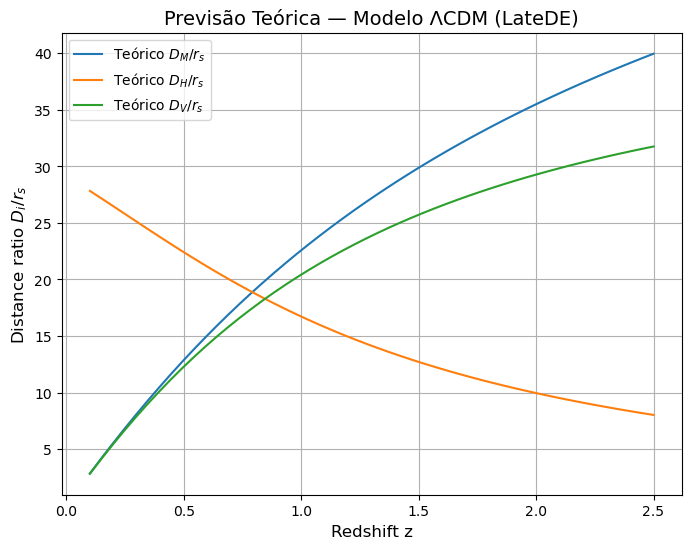

In [4]:
plt.figure(figsize=(8,6))
plt.plot(z_model, DM_model, label=r'Teórico $D_M/r_s$', color='tab:blue')
plt.plot(z_model, DH_model, label=r'Teórico $D_H/r_s$', color='tab:orange')
plt.plot(z_model, DV_model, label=r'Teórico $D_V/r_s$', color='tab:green')

plt.xlabel('Redshift z', fontsize=12)
plt.ylabel(r'Distance ratio $D_i / r_s$', fontsize=12)
plt.title('Previsão Teórica — Modelo ΛCDM (LateDE)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()